## Facial Emotion Recognition (FER) Training
**Model**: ResNet18 (Transfer Learning) a specific CNN architecture
**Phase 1**: Train on FER2013  
**Phase 2**: Fine-tune on CK+

---
### Emotion Classes (7)
| ID | Emotion   |
|----|----------|
| 0  | Angry    |
| 1  | Disgust  |
| 2  | Fear     |
| 3  | Happy    |
| 4  | Sad      |
| 5  | Surprise |
| 6  | Neutral  |

## Imports & Config

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Config
CONFIG = {

    'fer_csv_path':   'train.csv',       # FER2013 CSV
    'ck_csv_path':    'ckextended.csv',    # CK+ CSV (used in Phase 2)
    'checkpoint_dir': 'checkpoints/',

    # Training Hyperparameters
    'img_size':       48,
    'batch_size':     64,
    'num_epochs':     60,
    'lr':             1e-3,
    'weight_decay':   1e-4,
    'num_classes':    7,
    'patience':       10,    # early stopping
    'label_smoothing': 0.1,
}

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
print('Config loaded')

Using device: cuda
GPU: Tesla T4
Config loaded


## FER2013 Dataset Class

In [3]:
class FER2013Dataset(Dataset):
    """
    Loads FER2013 from CSV.
    Columns expected: 'emotion', 'pixels'
    """
    def __init__(self, dataframe, transform=None):
        self.data      = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row    = self.data.iloc[idx]
        label  = int(row['emotion'])
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        image  = Image.fromarray(pixels).convert('RGB')   # grayscale → RGB for ResNet

        if self.transform:
            image = self.transform(image)

        return image, label


def load_fer2013(csv_path):
    """Load and split FER2013 CSV into train / val / test dataframes."""
    print(f"Attempting to load {csv_path}...")

    # Load CSV, skipping bad lines
    try:
        df = pd.read_csv(csv_path, on_bad_lines='skip')
    except TypeError:
        # Fallback
        df = pd.read_csv(csv_path, error_bad_lines=False)

    print(f"Successfully loaded {len(df)} rows (corrupted lines skipped).")

    # Stratified split
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['emotion'])
    val, test = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['emotion'])
    train = train_df
    print(f'FER2013 → Train: {len(train)}  Val: {len(val)}  Test: {len(test)}')
    return train, val, test


def compute_class_weights(train_df):
    """class weights to handle imbalance."""
    counts  = train_df['emotion'].value_counts().sort_index().values
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(counts)   # normalize
    print('Class weights:', {EMOTION_LABELS[i]: f'{w:.3f}' for i, w in enumerate(weights)})
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


print('Dataset class defined')

Dataset class defined


## Transforms & DataLoaders

In [4]:
# ImageNet normalization (required for pretrained ResNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def get_fer_loaders(csv_path):
    train_df, val_df, test_df = load_fer2013(csv_path)

    train_ds = FER2013Dataset(train_df, transform=train_transform)
    val_ds   = FER2013Dataset(val_df,   transform=val_transform)
    test_ds  = FER2013Dataset(test_df,  transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                              shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=2, pin_memory=True)

    class_weights = compute_class_weights(train_df)
    return train_loader, val_loader, test_loader, class_weights


print('Transforms defined')

Transforms defined


## Model Architecture (ResNet18 + Custom Head)

In [5]:
class FERResNet(nn.Module):
    """
    ResNet18 backbone with a custom emotion classification head.
    Dropout added for regularization on the small FER dataset.
    """
    def __init__(self, num_classes=7, dropout=0.4, freeze_until_layer=None):
        super().__init__()
        # Pretrained ResNet18 backbone
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # freeze early layers (useful for fine-tuning on CK+)
        if freeze_until_layer:
            layers_to_freeze = ['conv1', 'bn1', 'layer1', 'layer2']
            for name, param in base.named_parameters():
                if any(name.startswith(l) for l in layers_to_freeze[:freeze_until_layer]):
                    param.requires_grad = False

        in_features = base.fc.in_features
        base.fc = nn.Identity()        # Remove original classifier
        self.backbone = base

        # Custom emotion head
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_trainable_params(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')


# Quick sanity check
model = FERResNet(num_classes=CONFIG['num_classes']).to(DEVICE)
model.get_trainable_params()
dummy = torch.randn(2, 3, 48, 48).to(DEVICE)
out   = model(dummy)
print(f'Output shape: {out.shape}  ← should be [2, 7]')

Trainable params: 11,342,151 / 11,342,151 (100.0%)
Output shape: torch.Size([2, 7])  ← should be [2, 7]


## Mixup Augmentation (Reduces Overfitting)

In [6]:
def mixup_data(x, y, alpha=0.2):
    """
    Mixup augmentation: blends two training samples.
    Significantly reduces overfitting on FER2013.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    index      = torch.randperm(batch_size).to(x.device)

    mixed_x  = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print('Mixup augmentation defined')

Mixup augmentation defined


##  Training & Validation Loops

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, use_mixup=True):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.2)

        optimizer.zero_grad()

        # Mixed precision for speed
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            outputs = model(images)
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / total, 100.0 * correct / total


print('Training loops defined')

Training loops defined


## Main Training Loop (Phase 1: FER2013)

In [8]:
def train_model(model, train_loader, val_loader, class_weights,
                num_epochs, lr, checkpoint_name='best_fer_model.pth',
                use_mixup=True):
    """
    Full training loop with:
      - Label smoothing loss
      - Cosine annealing LR scheduler
      - Mixed precision (AMP)
      - Early stopping
      - Best model checkpointing
    """
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=CONFIG['label_smoothing']
    )
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=CONFIG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [], 'lr': []
    }

    best_val_acc   = 0.0
    patience_count = 0
    checkpoint_path = os.path.join(CONFIG['checkpoint_dir'], checkpoint_name)

    print(f'\n{"="*60}')
    print(f'Training for {num_epochs} epochs on {DEVICE}')
    print(f'{"="*60}\n')

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, use_mixup
        )
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()

        current_lr = scheduler.get_last_lr()[0]
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f'Epoch [{epoch:>3}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  '
              f'Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%  '
              f'LR: {current_lr:.2e}')

        # Checkpoint best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_count = 0
            torch.save({
                'epoch':      epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc':    val_acc,
                'config':     CONFIG,
            }, checkpoint_path)
            print(f' New best Val Acc: {best_val_acc:.2f}% — checkpoint saved')
        else:
            patience_count += 1
            if patience_count >= CONFIG['patience']:
                print(f'\n⏹️  Early stopping triggered at epoch {epoch}')
                break

    print(f'\n Best Val Accuracy: {best_val_acc:.2f}%')
    return history, checkpoint_path

train_loader, val_loader, test_loader, class_weights = get_fer_loaders(CONFIG['fer_csv_path'])

model = FERResNet(num_classes=CONFIG['num_classes']).to(DEVICE)

history, best_ckpt = train_model(
    model, train_loader, val_loader, class_weights,
    num_epochs=CONFIG['num_epochs'],
    lr=CONFIG['lr'],
    checkpoint_name='best_fer_model.pth',
    use_mixup=True
)

Attempting to load train.csv...
Successfully loaded 28709 rows (corrupted lines skipped).
FER2013 → Train: 20096  Val: 4306  Test: 4307
Class weights: {'Angry': '0.480', 'Disgust': '4.399', 'Fear': '0.468', 'Happy': '0.266', 'Sad': '0.397', 'Surprise': '0.604', 'Neutral': '0.386'}


/tmp/ipython-input-64304398.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))



Training for 60 epochs on cuda



Training:   0%|          | 0/314 [00:00<?, ?it/s]/tmp/ipython-input-2575568185.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch [  1/60]  Train Loss: 2.0211  Train Acc: 17.16%  Val Loss: 1.8848  Val Acc: 37.04%  LR: 9.99e-04
 New best Val Acc: 37.04% — checkpoint saved


...

Epoch [ 56/60]  Train Loss: 1.4744  Train Acc: 44.43%  Val Loss: 1.4913  Val Acc: 63.56%  LR: 1.19e-05


Epoch [ 57/60]  Train Loss: 1.5239  Train Acc: 40.22%  Val Loss: 1.4875  Val Acc: 63.75%  LR: 7.15e-06
 New best Val Acc: 63.75% — checkpoint saved


Epoch [ 58/60]  Train Loss: 1.4992  Train Acc: 44.48%  Val Loss: 1.4869  Val Acc: 63.68%  LR: 3.74e-06


Epoch [ 59/60]  Train Loss: 1.5024  Train Acc: 43.89%  Val Loss: 1.4895  Val Acc: 63.91%  LR: 1.68e-06
 New best Val Acc: 63.91% — checkpoint saved


Epoch [ 60/60]  Train Loss: 1.4740  Train Acc: 42.09%  Val Loss: 1.4853  Val Acc: 63.66%  LR: 1.00e-06

 Best Val Accuracy: 63.91%


##  Training Curves

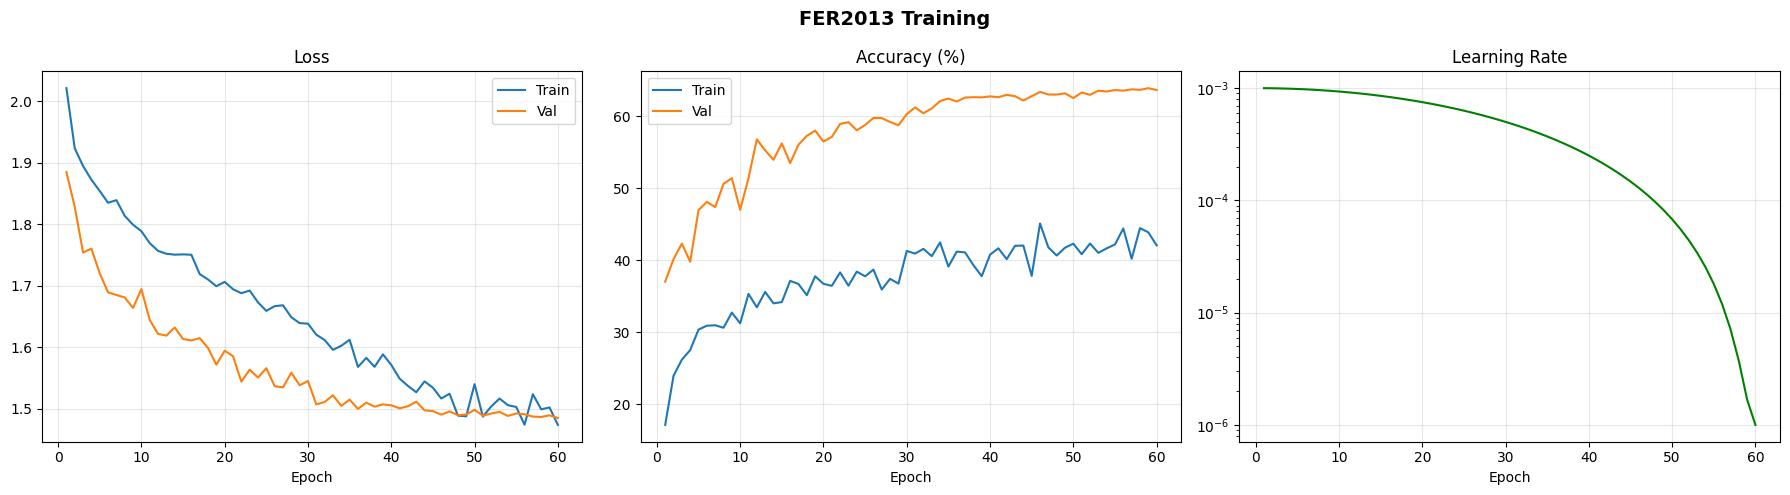

Training curves saved


In [9]:
def plot_history(history, title='FER2013 Training'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Learning Rate
    axes[2].plot(epochs, history['lr'], color='green')
    axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')
    axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Training curves saved')


plot_history(history)

##  Evaluate on Test Set + Confusion Matrix

Loaded checkpoint from epoch 59 (Val Acc: 63.91%)



Evaluating: 100%|██████████| 68/68 [00:03<00:00, 21.09it/s]


Classification Report:
              precision    recall  f1-score   support

       Angry       0.55      0.56      0.56       599
     Disgust       0.42      0.69      0.52        65
        Fear       0.52      0.38      0.44       615
       Happy       0.87      0.83      0.85      1083
         Sad       0.50      0.52      0.51       725
    Surprise       0.72      0.78      0.75       475
     Neutral       0.58      0.66      0.62       745

    accuracy                           0.64      4307
   macro avg       0.60      0.63      0.61      4307
weighted avg       0.64      0.64      0.64      4307



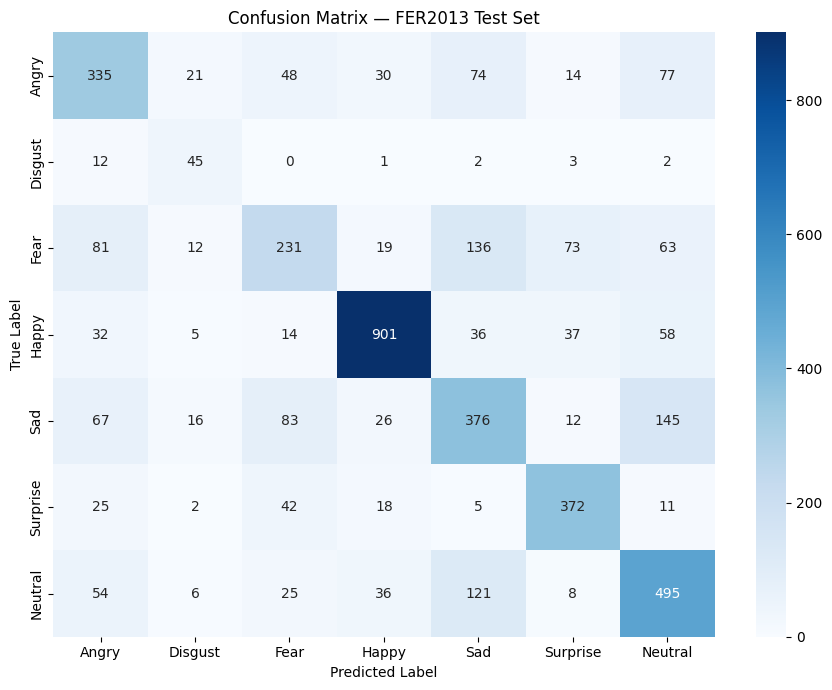

In [10]:
@torch.no_grad()
def evaluate_model(checkpoint_path, test_loader):
    """Load best checkpoint and run full evaluation."""
    # Load best model
    model = FERResNet(num_classes=CONFIG['num_classes']).to(DEVICE)
    ckpt  = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f"Loaded checkpoint from epoch {ckpt['epoch']} (Val Acc: {ckpt['val_acc']:.2f}%)\n")

    all_preds, all_labels = [], []

    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

    # Classification report
    print('Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
    plt.title('Confusion Matrix — FER2013 Test Set')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return model


trained_model = evaluate_model(best_ckpt, test_loader)

## Sample Predictions Visualizer

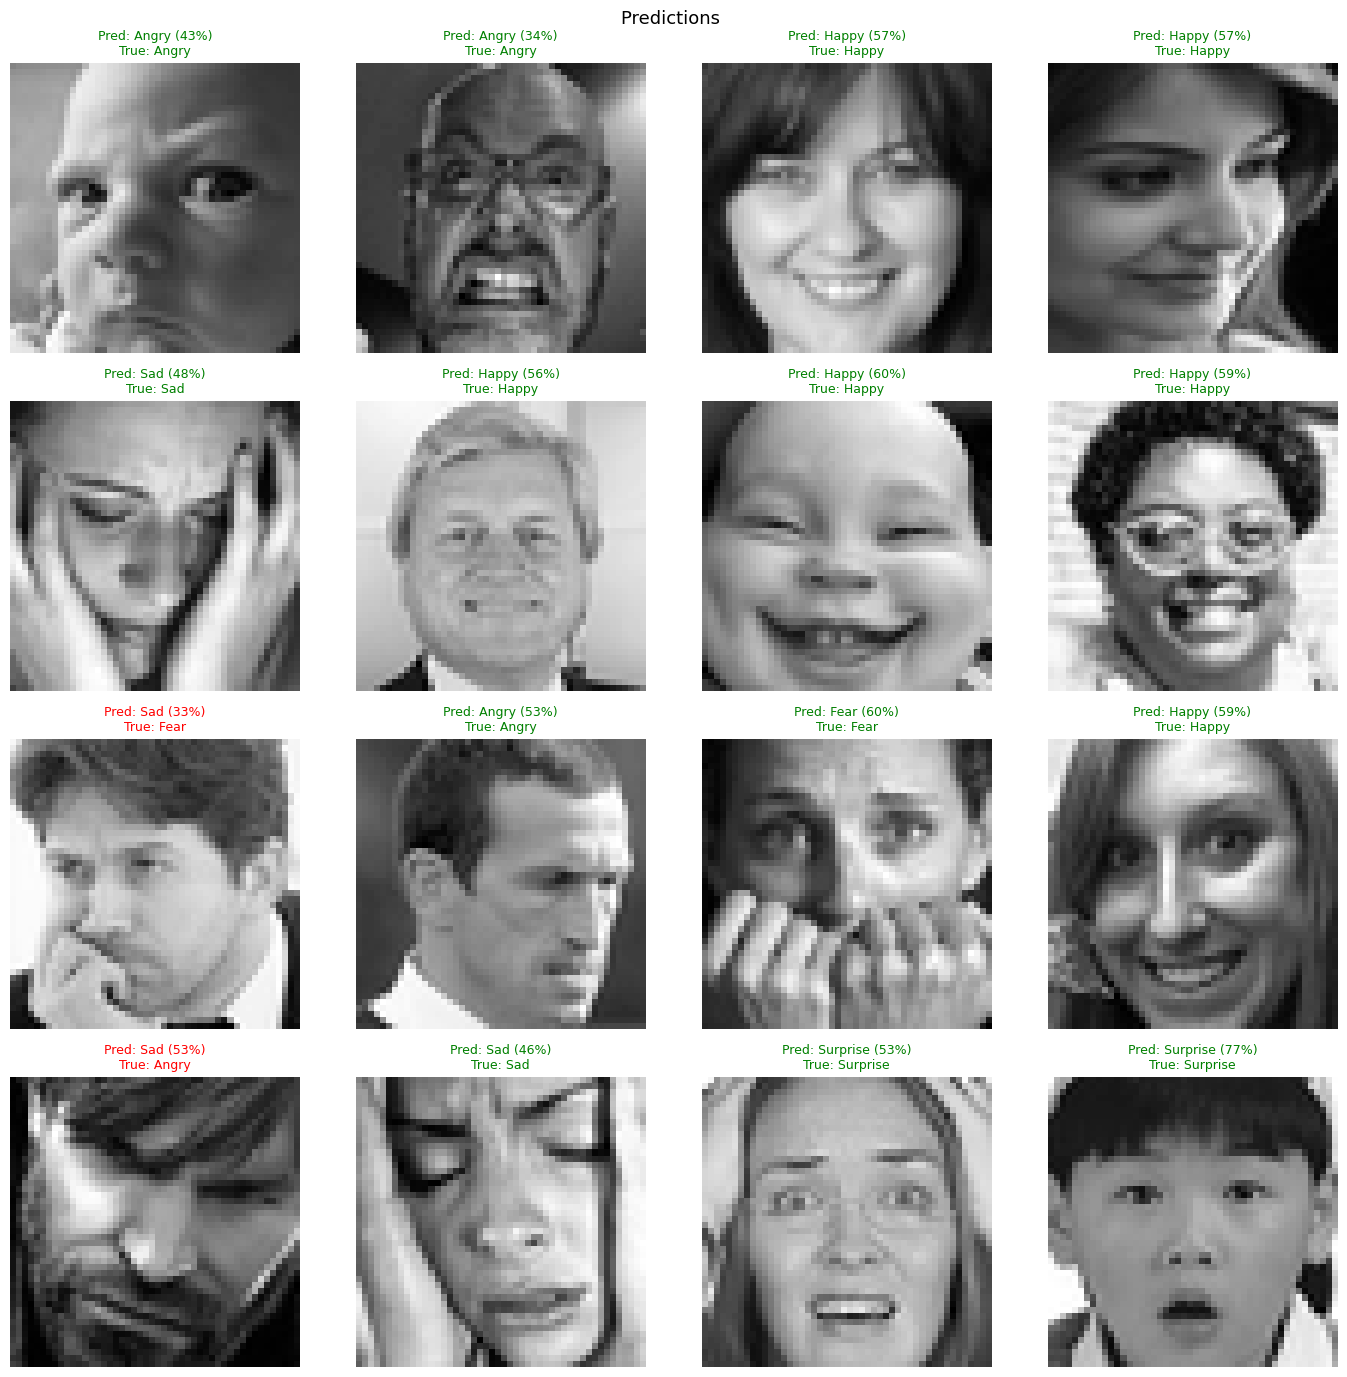

In [11]:
@torch.no_grad()
def visualize_predictions(model, loader, num_samples=16):
    """Show a grid of predictions vs ground truth."""
    model.eval()
    images, labels = next(iter(loader))
    images_dev = images.to(DEVICE)
    outputs    = model(images_dev)
    probs      = torch.softmax(outputs, dim=1)
    confs, preds = probs.max(1)

    IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(3,1,1)

    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle('Predictions ', fontsize=13)

    for i, ax in enumerate(axes.flat):
        if i >= num_samples: break
        img = images[i] * IMAGENET_STD_T + IMAGENET_MEAN_T
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        img_gray = img.mean(axis=2)

        pred_label  = EMOTION_LABELS[preds[i].item()]
        true_label  = EMOTION_LABELS[labels[i].item()]
        conf        = confs[i].item() * 100
        correct     = preds[i].item() == labels[i].item()

        ax.imshow(img_gray, cmap='gray')
        color = 'green' if correct else 'red'
        ax.set_title(f'Pred: {pred_label} ({conf:.0f}%)\nTrue: {true_label}',
                     color=color, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(trained_model, test_loader)


---
# PHASE 2 — Fine-Tune on CK+
> **After having a good accuracy percentage then proceed with fine tuning.**

## CK+ Dataset Class

In [12]:
import pandas as pd
df = pd.read_csv('ckextended.csv')

# Check this
print(df.columns.tolist())
print(df['emotion'].value_counts().sort_index())
print(df.head())

['emotion', 'pixels', 'Usage']
emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64
   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training


In [15]:
import pandas as pd
df = pd.read_csv('ckextended.csv')

# Check this
print(df.columns.tolist())
print(df['emotion'].value_counts().sort_index())
print(df.head())

#  CK+ → FER2013 label mapping 

# FER2013 encoding:
#   0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral

CK_TO_FER_MAP = {
    0: 0,    # Anger    → Angry
    1: 1,    # Disgust  → Disgust
    2: 2,    # Fear     → Fear
    3: 3,    # Happiness→ Happy
    4: 4,    # Sadness  → Sad
    5: 5,    # Surprise → Surprise
    6: 6,    # Neutral  → Neutral
    7: None, # Contempt → DROP
}

class CKPlusDataset(Dataset):
    """
    CK+ Dataset from CSV.
    """
    def __init__(self, dataframe, transform=None):
        # Remap labels and drop unmapped (e.g. Contempt)
        df = dataframe.copy()
        df['emotion'] = df['emotion'].map(CK_TO_FER_MAP)
        df = df.dropna(subset=['emotion'])
        df['emotion'] = df['emotion'].astype(int)

        self.data      = df.reset_index(drop=True)
        self.transform = transform

        print(f'CK+ dataset: {len(self.data)} samples after label mapping')
        print('Class distribution:')
        for eid, count in self.data['emotion'].value_counts().sort_index().items():
            print(f'  {EMOTION_LABELS[eid]:>10}: {count}')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        label = int(row['emotion'])

        # pixels column (same as FER2013) 
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        image  = Image.fromarray(pixels).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


def load_ck_loaders(csv_path, val_split=0.15, test_split=0.15):
    """
    Load CK+ CSV and split by SUBJECT to prevent data leakage.
    If no 'subject_id' column exists, falls back to random split.
    """
    df = pd.read_csv(csv_path)

    if 'subject_id' in df.columns:
        # Subject-stratified split to prevent leakage
        subjects = df['subject_id'].unique()
        np.random.shuffle(subjects)
        n        = len(subjects)
        n_val    = int(n * val_split)
        n_test   = int(n * test_split)

        test_subs  = subjects[:n_test]
        val_subs   = subjects[n_test:n_test + n_val]
        train_subs = subjects[n_test + n_val:]

        train_df = df[df['subject_id'].isin(train_subs)]
        val_df   = df[df['subject_id'].isin(val_subs)]
        test_df  = df[df['subject_id'].isin(test_subs)]
        print('Using subject-stratified split (no leakage) ✓')
    else:
        # Random split fallback
        from sklearn.model_selection import train_test_split
        train_df, temp = train_test_split(
            df, test_size=val_split+test_split,
            stratify=df['emotion'], 
            random_state=SEED)
        val_df,  test_df = train_test_split(
            temp, test_size=0.5,
            stratify=temp['emotion'],
            random_state=SEED)
        print('No subject_id column found using random split ')

    print(f'CK+ Split → Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

    # Stronger augmentation for fine-tuning on small dataset
    ck_train_transform = transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    train_ds = CKPlusDataset(train_df, transform=ck_train_transform)
    val_ds   = CKPlusDataset(val_df,   transform=val_transform)
    test_ds  = CKPlusDataset(test_df,  transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    ck_weights = compute_class_weights(train_ds.data)
    return train_loader, val_loader, test_loader, ck_weights


print('CK+ dataset class defined ')

['emotion', 'pixels', 'Usage']
emotion
0     45
1     59
2     25
3     69
4     28
5     83
6    593
7     18
Name: count, dtype: int64
   emotion                                             pixels     Usage
0        6  36 39 35 25 19 11 8 7 3 13 15 9 21 57 75 90 10...  Training
1        6  88 74 19 4 5 5 3 12 8 21 15 21 15 18 24 29 32 ...  Training
2        6  9 2 4 7 1 1 1 0 7 29 49 76 115 141 156 169 177...  Training
3        6  104 106 108 104 95 50 60 61 58 83 126 133 139 ...  Training
4        6  68 72 67 67 6 2 1 1 1 1 1 14 24 24 38 65 79 94...  Training
CK+ dataset class defined 


## Fine-Tune on CK+ (After Phase 1)

/tmp/ipython-input-64304398.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


Loaded FER2013 weights from epoch 59 ✓
Trainable params: 11,332,615 / 11,342,151 (99.9%)
No subject_id column found using random split 
CK+ Split → Train: 644  Val: 138  Test: 138
CK+ dataset: 631 samples after label mapping
Class distribution:
       Angry: 32
     Disgust: 41
        Fear: 17
       Happy: 48
         Sad: 20
    Surprise: 58
     Neutral: 415
CK+ dataset: 135 samples after label mapping
Class distribution:
       Angry: 6
     Disgust: 9
        Fear: 4
       Happy: 11
         Sad: 4
    Surprise: 12
     Neutral: 89
CK+ dataset: 136 samples after label mapping
Class distribution:
       Angry: 7
     Disgust: 9
        Fear: 4
       Happy: 10
         Sad: 4
    Surprise: 13
     Neutral: 89
Class weights: {'Angry': '1.067', 'Disgust': '0.833', 'Fear': '2.009', 'Happy': '0.712', 'Sad': '1.708', 'Surprise': '0.589', 'Neutral': '0.082'}

Training for 30 epochs on cuda



Training:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipython-input-2575568185.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):


Epoch [  1/30]  Train Loss: 1.7719  Train Acc: 50.87%  Val Loss: 1.7866  Val Acc: 70.37%  LR: 9.97e-05
 New best Val Acc: 70.37% — checkpoint saved


Epoch [  2/30]  Train Loss: 1.7355  Train Acc: 53.41%  Val Loss: 1.7024  Val Acc: 68.89%  LR: 9.89e-05


...

Epoch [ 26/30]  Train Loss: 1.2657  Train Acc: 73.69%  Val Loss: 1.3352  Val Acc: 82.96%  LR: 5.28e-06


Epoch [ 27/30]  Train Loss: 1.2610  Train Acc: 74.17%  Val Loss: 1.3350  Val Acc: 85.19%  LR: 3.42e-06


Epoch [ 28/30]  Train Loss: 1.2678  Train Acc: 72.11%  Val Loss: 1.3187  Val Acc: 85.19%  LR: 2.08e-06


Epoch [ 29/30]  Train Loss: 1.2198  Train Acc: 76.23%  Val Loss: 1.3260  Val Acc: 82.22%  LR: 1.27e-06


Epoch [ 30/30]  Train Loss: 1.1828  Train Acc: 76.86%  Val Loss: 1.3423  Val Acc: 82.22%  LR: 1.00e-06

⏹️  Early stopping triggered at epoch 30

 Best Val Accuracy: 85.19%


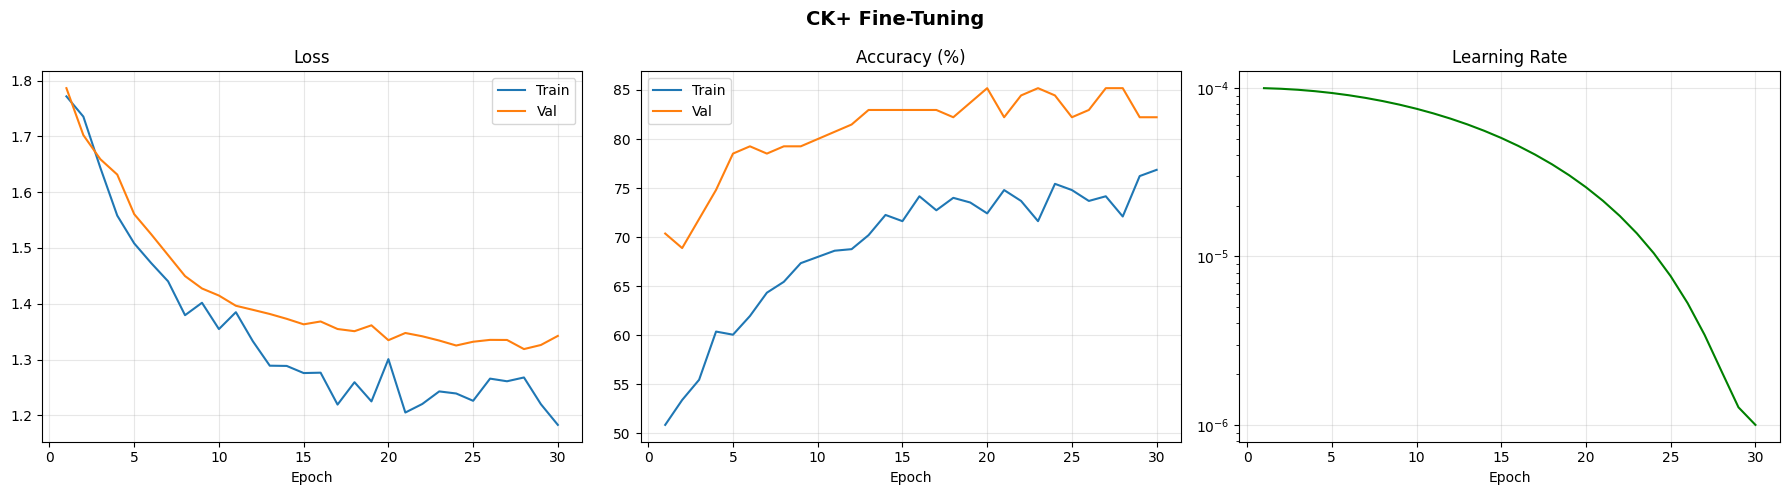

Training curves saved


In [16]:

#  PHASE 2: FINE-TUNE ON CK+
#  Loads best FER2013 checkpoint → freezes early layers → trains


FER_CHECKPOINT = os.path.join(CONFIG['checkpoint_dir'], 'best_fer_model.pth')

# Load FER2013-trained weights
finetune_model = FERResNet(num_classes=CONFIG['num_classes'],
                           freeze_until_layer=2).to(DEVICE)  # freeze conv1, bn1, layer1, layer2

ckpt = torch.load(FER_CHECKPOINT, map_location=DEVICE)
finetune_model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded FER2013 weights from epoch {ckpt['epoch']} ✓")
finetune_model.get_trainable_params()

# Load CK+ data
ck_train, ck_val, ck_test, ck_weights = load_ck_loaders(CONFIG['ck_csv_path'])

# Fine-tuning with small LR and fewer epochs
ck_history, ck_ckpt = train_model(
    finetune_model, ck_train, ck_val, ck_weights,
    num_epochs=30,
    lr=1e-4,
    checkpoint_name='best_ck_model.pth',
    use_mixup=False
)

plot_history(ck_history, title='CK+ Fine-Tuning')

## Evaluate Fine-Tuned Model on CK+ Test Set

Loaded checkpoint from epoch 20 (Val Acc: 85.19%)



Evaluating: 100%|██████████| 5/5 [00:00<00:00, 17.52it/s]


Classification Report:
              precision    recall  f1-score   support

       Angry       0.83      0.71      0.77         7
     Disgust       0.89      0.89      0.89         9
        Fear       0.36      1.00      0.53         4
       Happy       0.91      1.00      0.95        10
         Sad       0.38      0.75      0.50         4
    Surprise       0.93      1.00      0.96        13
     Neutral       1.00      0.87      0.93        89

    accuracy                           0.88       136
   macro avg       0.76      0.89      0.79       136
weighted avg       0.93      0.88      0.90       136



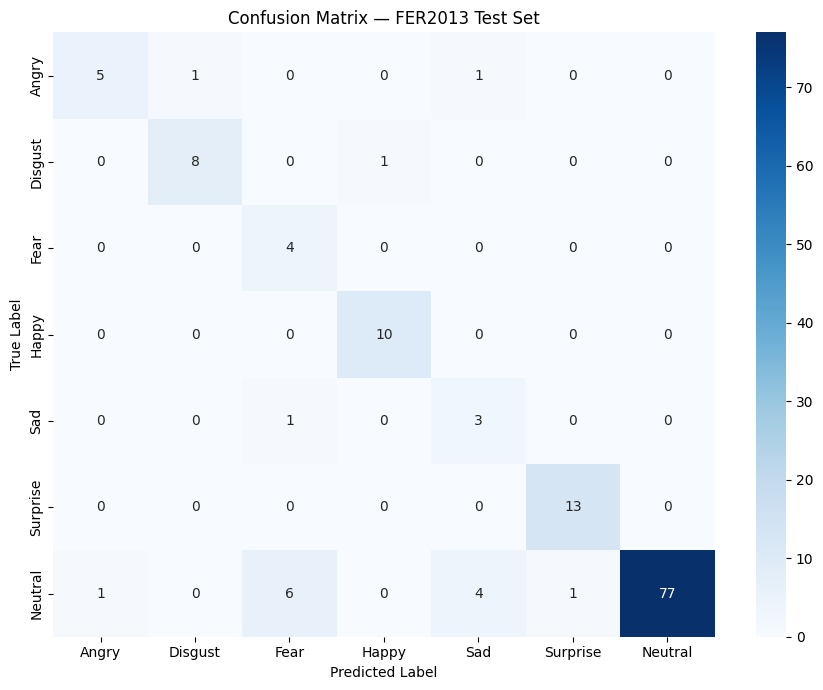

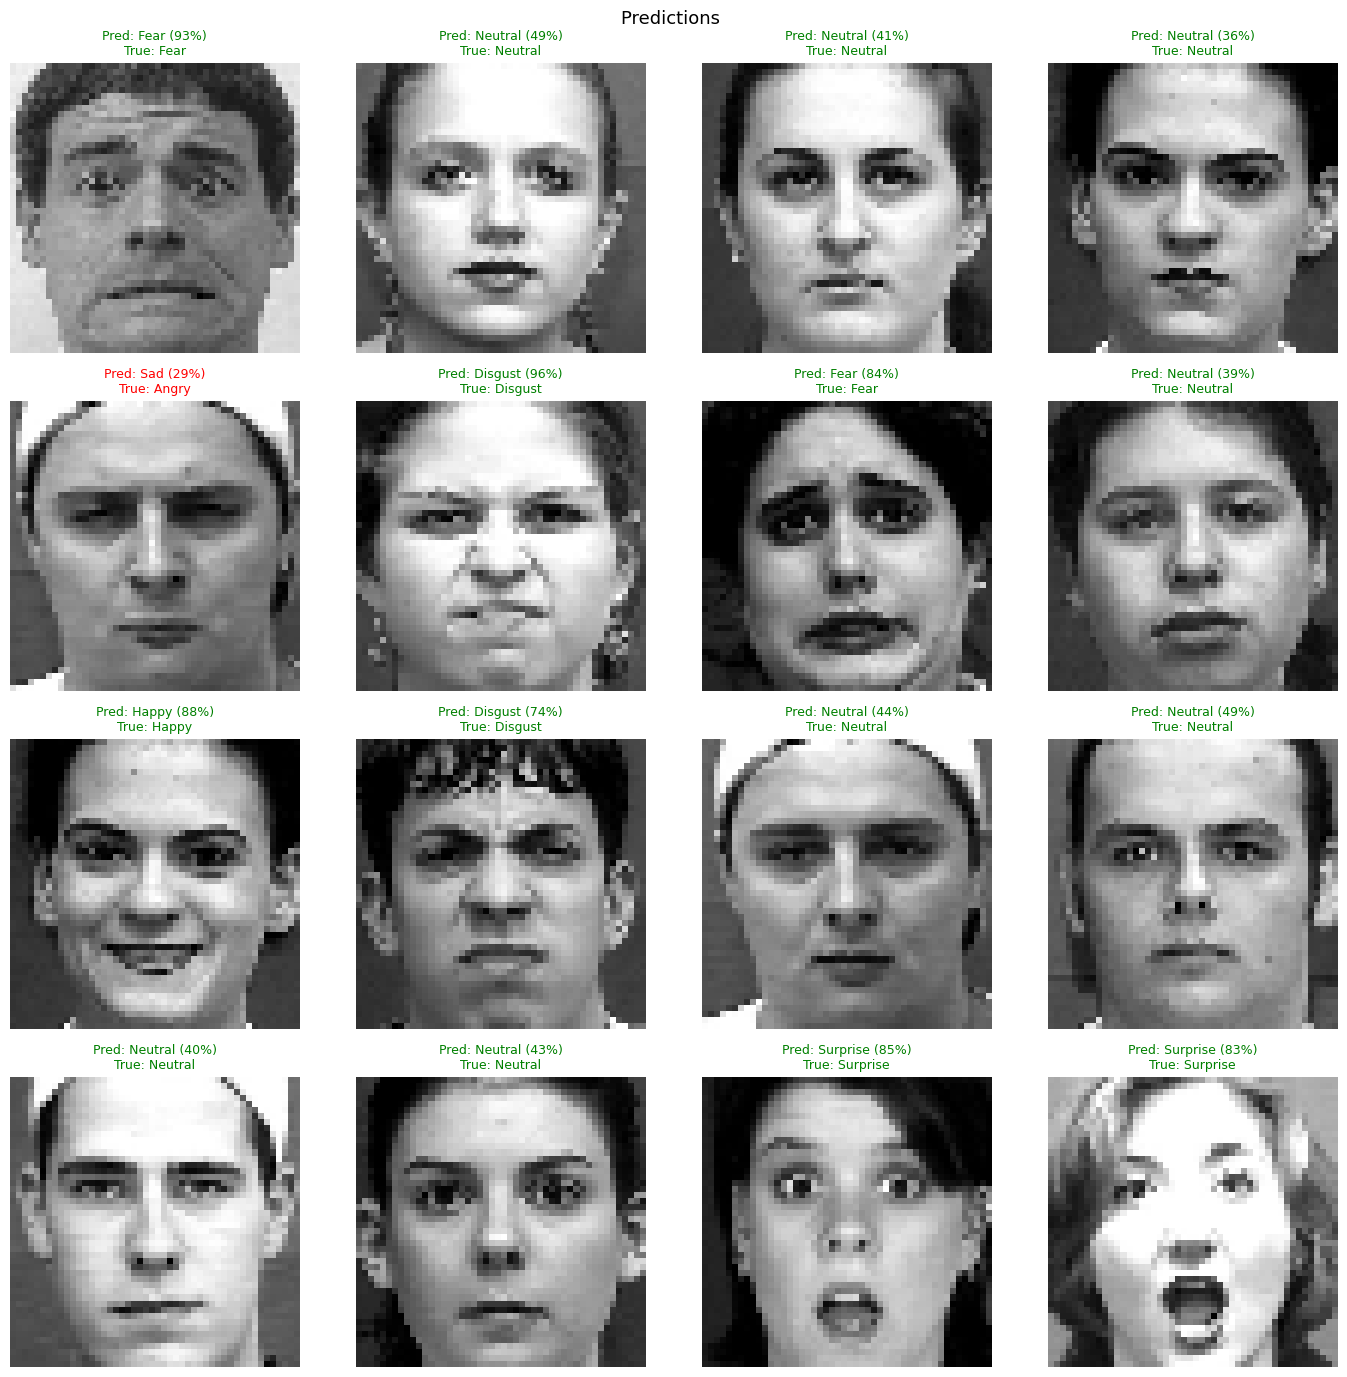

In [17]:
ck_best_model = evaluate_model(ck_ckpt, ck_test)
visualize_predictions(ck_best_model, ck_test)

##  Export for Flask API

In [19]:
def export_for_inference(checkpoint_path, output_path='fer_model_inference.pth'):
    """
    Export a clean model weights file for the Flask backend.
    """
    model = FERResNet(num_classes=CONFIG['num_classes']).to(DEVICE)
    ckpt  = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # Export lean weights
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes':      CONFIG['num_classes'],
        'emotion_labels':   EMOTION_LABELS,
        'img_size':         CONFIG['img_size'],
        'val_acc':          ckpt['val_acc'],
    }, output_path)

    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f'Exported: {output_path} ({size_mb:.1f} MB)')
    print(f'Val Accuracy at export: {ckpt["val_acc"]:.2f}%')
    print('\nLoad in Flask with:')
    print('  ckpt = torch.load("fer_model_inference.pth", map_location="cpu")')
    print('  model = FERResNet(num_classes=7)')
    print('  model.load_state_dict(ckpt["model_state_dict"])')
    print('  model.eval()')


# Export Phase 1 model and Phase 2 model
export_for_inference(best_ckpt,  output_path='fer_model_inference.pth')
export_for_inference(ck_ckpt,  output_path='fer_ck_finetuned_inference.pth')

Exported: fer_model_inference.pth (43.4 MB)
Val Accuracy at export: 63.91%

Load in Flask with:
  ckpt = torch.load("fer_model_inference.pth", map_location="cpu")
  model = FERResNet(num_classes=7)
  model.load_state_dict(ckpt["model_state_dict"])
  model.eval()
Exported: fer_ck_finetuned_inference.pth (43.4 MB)
Val Accuracy at export: 85.19%

Load in Flask with:
  ckpt = torch.load("fer_model_inference.pth", map_location="cpu")
  model = FERResNet(num_classes=7)
  model.load_state_dict(ckpt["model_state_dict"])
  model.eval()
